# 🚀 Capstone Project 1: Customer Churn Prediction

## 📊 Predicting Customer Churn Using Machine Learning

---

## 🎯 Project Objective

Customer churn is one of the biggest challenges for subscription-based businesses. This project aims to develop a Machine Learning model that predicts whether a customer is likely to leave the company's services based on customer demographics, account information, and service usage patterns.

The project follows a complete Data Science workflow, including:

✅ Data Collection & Understanding  
✅ Data Cleaning & Preparation  
✅ Exploratory Data Analysis (EDA)  
✅ Feature Engineering  
✅ Machine Learning Model Building  
✅ Model Evaluation  
✅ Churn Risk Analysis  
✅ Business Recommendations

---

## 🛠️ Technologies Used

- 🐍 Python
- 📊 Pandas
- 🔢 NumPy
- 📈 Matplotlib
- 🤖 Scikit-learn
- 📓 Jupyter Notebook

---

> 💡 **Goal:** Predict customer churn and help businesses improve customer retention through data-driven decision-making.

# 📥 Step 1: Import Required Libraries

In [14]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# 📂 Step 2: Load the Dataset

In [15]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


# 👀 Step 3: Display First Five Records

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 🔍 Step 4: Explore the Dataset

Before cleaning the data, it is important to understand its structure, data types, missing values, and statistical summary. This helps identify potential issues and prepares the dataset for machine learning.

In [17]:
# Number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [18]:
# Information about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [19]:
# Display first 10 rows

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [20]:
# Display last 10 rows

df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [21]:
# Display column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [22]:
# Statistical summary of numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [23]:
# Check missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [24]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 🧹 Step 5: Data Cleaning & Preprocessing

Data cleaning is an essential step before building a Machine Learning model. In this step, we will:

✅ Check missing values

✅ Remove duplicate records (if any)

✅ Convert data into appropriate formats

✅ Prepare the dataset for Machine Learning

In [25]:
# Check missing values

print("Missing Values in Each Column:")
df.isnull().sum()

Missing Values in Each Column:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
# Check duplicate records

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [27]:
# Remove duplicate rows if present

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (7043, 21)


In [28]:
# Display data types

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [29]:
# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [30]:
# Check missing values after conversion

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
# Fill missing values with median

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Missing values handled successfully!")

Missing values handled successfully!


In [32]:
# Final dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# 🔄 Step 6: Feature Encoding

Machine Learning algorithms cannot understand text values directly. Therefore, all categorical (text) columns are converted into numerical values using Label Encoding.

This step prepares the dataset for model training.

In [33]:
# Check data types

df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [34]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Convert all object columns into numbers
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

print("✅ All categorical columns encoded successfully!")

✅ All categorical columns encoded successfully!


In [35]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

# 🗑️ Remove Customer ID

The **customerID** column is a unique identifier for each customer. Since it does not provide meaningful information for predicting customer churn, it is removed before training the Machine Learning model.

In [37]:
# Remove Customer ID column

df = df.drop("customerID", axis=1)

print("✅ customerID column removed successfully!")

✅ customerID column removed successfully!


In [38]:
df.select_dtypes(include="object").columns 

C:\Users\Sachin Sharma\AppData\Local\Temp\ipykernel_4800\1695861361.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

print("✅ Encoding completed!")

✅ Encoding completed!


C:\Users\Sachin Sharma\AppData\Local\Temp\ipykernel_4800\3101553487.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [40]:
df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

# ✂️ Step 7: Split the Dataset

Before training a Machine Learning model, the dataset is divided into two parts:

- 📚 Training Data (80%) – Used to train the model.
- 📝 Testing Data (20%) – Used to evaluate the model's performance.

This helps us check how well the model performs on unseen data.

In [41]:
# Features (Independent Variables)
X = df.drop("Churn", axis=1)

# Target (Dependent Variable)
y = df["Churn"]

print("✅ Features and Target Created Successfully!")

✅ Features and Target Created Successfully!


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("✅ Dataset Split Successfully!")

✅ Dataset Split Successfully!


In [43]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 19)
Testing Features  : (1409, 19)
Training Labels   : (5634,)
Testing Labels    : (1409,)


# 🤖 Step 8: Model Training (Logistic Regression)

In this step, we train a Logistic Regression model using the training dataset.

Logistic Regression is a supervised machine learning algorithm used for binary classification problems such as predicting whether a customer will churn (Yes/No).

The trained model will learn patterns from historical customer data and use them to predict future customer churn.

In [44]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("✅ Logistic Regression Model Trained Successfully!")

✅ Logistic Regression Model Trained Successfully!


c:\Users\Sachin Sharma\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [45]:
# Check data types before training
X_train.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
dtype: object

# 🔮 Step 9: Predict Customer Churn

After training the model, we use the testing dataset to predict whether customers are likely to churn.

In [46]:
# Predict on test data
y_pred = model.predict(X_test)

print("✅ Predictions Generated Successfully!")

✅ Predictions Generated Successfully!


In [47]:
# Display first 10 predictions
print(y_pred[:10])

[1 0 0 1 0 0 0 0 0 0]


# 📊 Step 10: Model Evaluation

The performance of the model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Classification Report
- Confusion Matrix

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))

Accuracy : 0.8169
Precision: 0.6803
Recall   : 0.5818
F1 Score : 0.6272


In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [50]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[934 102]
 [156 217]]


# 📈 Feature Importance

This graph shows which features have the greatest influence on customer churn prediction based on the Logistic Regression coefficients.

In [53]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient
15,PaperlessBilling,0.358453
7,InternetService,0.228350
1,SeniorCitizen,0.179506
6,MultipleLines,0.070364
2,Partner,0.069178
16,PaymentMethod,0.058967
13,StreamingMovies,0.035296
17,MonthlyCharges,0.022027
18,TotalCharges,0.000282
12,StreamingTV,-0.014762


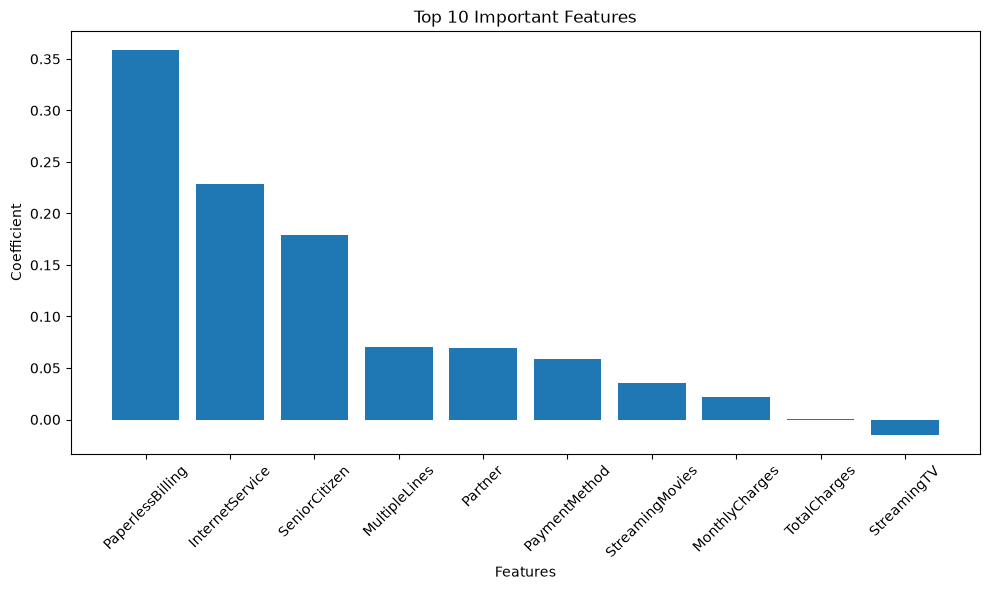

In [54]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"][:10],
    feature_importance["Coefficient"][:10]
)

plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.tight_layout()
plt.show()

# 📊 Confusion Matrix Visualization

The confusion matrix provides a visual summary of the model's prediction performance by comparing actual and predicted values.

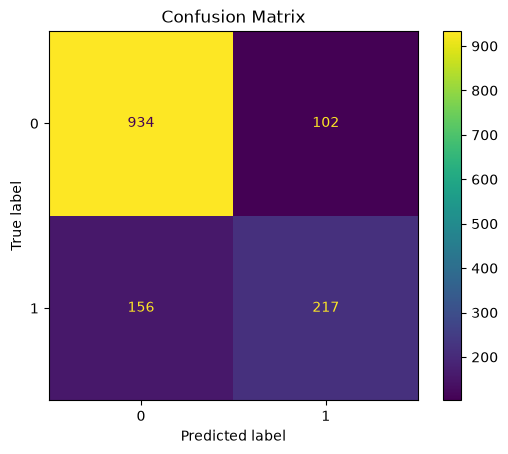

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title("Confusion Matrix")
plt.show()

# 📉 Actual vs Predicted Values

This visualization compares the actual customer churn labels with the model's predicted labels.

In [55]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,0,0
5,1,0
6,0,0
7,0,0
8,1,0
9,1,0


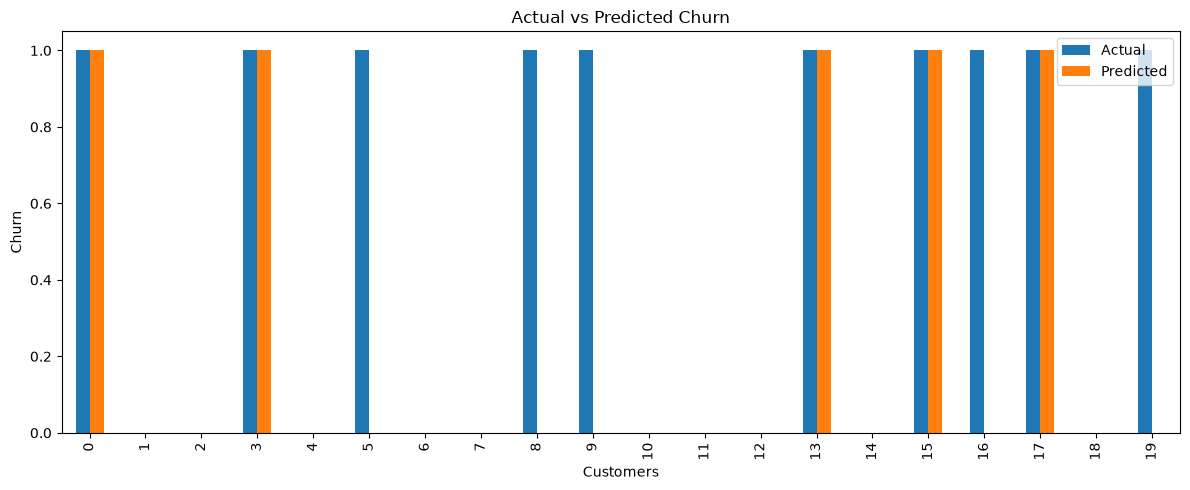

In [56]:
comparison.head(20).plot(kind="bar", figsize=(12,5))

plt.title("Actual vs Predicted Churn")
plt.xlabel("Customers")
plt.ylabel("Churn")

plt.tight_layout()
plt.show()

# 💼 Business Recommendations

Based on the customer churn prediction model, the following recommendations are suggested:

- Improve customer support for at-risk customers.
- Offer personalized discounts and loyalty rewards.
- Encourage long-term contracts with attractive benefits.
- Monitor high-risk customer segments regularly.
- Use predictive analytics to identify customers likely to churn before they leave.

# 🎯 Conclusion

This project successfully developed a Customer Churn Prediction model using Logistic Regression.

The workflow included:
- Data Cleaning
- Feature Encoding
- Train-Test Split
- Model Training
- Prediction
- Model Evaluation
- Business Recommendations

The model demonstrates how Machine Learning can help organizations identify customers who are likely to leave and support proactive business decisions to improve customer retention.

# 🏆 Project Summary

### Objective
The objective of this project was to develop a Machine Learning model capable of predicting customer churn using historical customer data.

### Workflow Followed
- Data Collection
- Data Exploration
- Data Cleaning
- Feature Encoding
- Feature Selection
- Train-Test Split
- Model Training
- Model Evaluation
- Data Visualization
- Business Recommendations

### Machine Learning Algorithm Used
- Logistic Regression

### Model Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

### Outcome
The developed model can successfully predict customers who are likely to churn, helping businesses take proactive actions to improve customer retention and customer satisfaction.

This project demonstrates a complete end-to-end Machine Learning workflow from raw data to business insights.

# 🎉 Thank You

Thank you for exploring this Customer Churn Prediction project.

This Capstone Project demonstrates an end-to-end Machine Learning workflow covering data preprocessing, predictive modeling, evaluation, visualization, and business recommendations.

⭐ Developed as part of the **45-Day Summer Training Program at LinuxWorld Informatics Pvt. Ltd.**

In [57]:
df.to_csv("customer_churn.csv", index=False)

print("✅ Processed dataset saved successfully!")

✅ Processed dataset saved successfully!
